In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot(xs, ys_alg1, ys_alg24, plot_path, palette=None, dataset="dataset"):
    xs = np.asarray(xs)
    y1 = np.asarray(ys_alg1, dtype=float)
    y2 = np.asarray(ys_alg24, dtype=float)

    # keep log-safe
    def _safe_log(arr):
        if np.any(arr <= 0):
            pos_min = arr[arr > 0].min() if np.any(arr > 0) else 1e-6
            eps = max(pos_min * 1e-3, 1e-9)
            return np.where(arr <= 0, eps, arr)
        return arr

    y1 = _safe_log(y1)
    y2 = _safe_log(y2)

    # dark blue & dark orange by default (avoid seaborn defaults)
    if palette is None:
        palette = ["#1f3a93", "#d35400"]

    sns.set_theme(style="whitegrid")
    sns.set(rc={"axes.labelweight": "bold"})  # bold axis labels

    fig, ax = plt.subplots(figsize=(5.2, 3.0))
    # plot
    sns.lineplot(x=xs, y=y1, marker="o", label="CD", ax=ax, color=palette[0])
    sns.lineplot(x=xs, y=y2, marker="s", label="MI", ax=ax, color=palette[1], dashes=(3, 2))

    # labels & scale
    ax.set_xlabel("Number of attributes", fontweight="bold")
    ax.set_ylabel("Execution time (s)", fontweight="bold")
    ax.set_yscale("log")

    # integer ticks only (no 0.5)
    xs_int = np.asarray(xs, dtype=int)
    ax.set_xticks(xs_int)
    ax.set_xticklabels([str(v) for v in xs_int])
    ax.margins(x=0.02)

    # title: only first letter uppercase
    if isinstance(dataset, str) and dataset:
        title_text = dataset[0].upper() + dataset[1:]
    else:
        title_text = str(dataset)
    ax.set_title(title_text, fontweight="bold")

    ax.legend(loc="upper left", frameon=True)
    fig.tight_layout()
    #fig.savefig(plot_path, dpi=160)
    plt.show()
    plt.close(fig)


In [3]:
#read data from file
dataset="census"
import pandas as pd
import os
PATH="../tables/"
df=pd.read_csv(os.path.join(PATH,f"{dataset}_3_time_vs_num_attrs.csv"))
df.head()

,timestamp,k_attrs,cols_json,domain_size,levels_json,probs_json,time_alg1_first_s,num_edges_alg1,time_alg2_s,time_alg4_s,time_alg24_s,q_base_groups,q_star_groups,merges_alg2,utility_q_babble,utility_q_base,utility_q_star,kept_q_babble,kept_q_base,kept_q_star
0,2025-10-13 13:02:03,1,"[""sex""]",2,"[0.6666666666666666, 0.6666666666666666, 0.333...","[0.25, 0.25, 0.25, 0.25]",0.000015,0,0.000020,0.000017,0.000036,1,1,1,0.666667,0.666667,0.666667,1,1,1
1,2025-10-13 13:02:03,2,"[""sex"", ""race""]",10,"[0.9090909090909091, 0.7272727272727273, 0.454...","[0.25, 0.25, 0.25, 0.25]",0.000045,32,0.000115,0.000368,0.000482,9,5,1,2.000000,1.727273,2.000000,5,3,5
2,2025-10-13 13:02:04,3,"[""sex"", ""race"", ""education_num""]",160,"[0.9937888198757764, 0.7453416149068323, 0.496...","[0.25, 0.25, 0.25, 0.25]",0.023730,8618,0.021762,0.912999,0.934761,159,2,1,37.347826,36.658385,47.770186,73,52,78


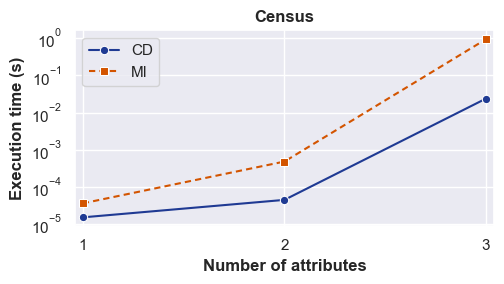

In [4]:
#drop the row with max ys_alg24

xs=df["k_attrs"].tolist()
ys_alg1=df["time_alg1_first_s"].tolist()
ys_alg24=df["time_alg24_s"].tolist()
#make milisecond second

#keep on 3 values in ys_alg24, xs, ys_alg1
ys_alg1=ys_alg1[:3]
ys_alg24=ys_alg24[:3]
xs=xs[:3]

plot(xs, ys_alg1, ys_alg24, f"{dataset}_time_vs_num_attrs.png",dataset=dataset)

Plotting average utility gained vs baseline utility

In [146]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = PATH  # keep your existing PATH
compas_csv  = os.path.join(PATH, "census_3_time_vs_num_attrs.csv")
census_csv  = os.path.join(PATH, "census_3_time_vs_num_attrs.csv")  # adjust if your filename differs
plot_path   = os.path.join(PATH, "avg_utility_by_dataset.png")

# --- load
compas = pd.read_csv(compas_csv).assign(dataset="COMPAS")
census = pd.read_csv(census_csv).assign(dataset="Census")

# keep only what we need; rename for consistency if you like
use_cols = ["dataset", "kept_q_babble", "kept_q_star"]
df = pd.concat([compas[use_cols], census[use_cols]], ignore_index=True)

# --- long form: algorithm | utility
long = df.melt(
    id_vars=["dataset"],
    value_vars=["kept_q_babble", "kept_q_star"],
    var_name="algorithm",
    value_name="utility",
)
long["algorithm"] = long["algorithm"].map({
    "kept_q_babble": "Initial Query",
    "kept_q_star": "Maximally Informative",
})

# --- aggregate mean per dataset/algorithm
agg = long.groupby(["dataset", "algorithm"], as_index=False)["utility"].mean()

# --- plot
sns.set_theme(style="whitegrid")
sns.set(rc={"axes.labelweight": "bold"})  # bold axis labels

fig, ax = plt.subplots(figsize=(5.2, 3.0))
sns.barplot(
    data=agg,
    x="dataset",
    y="utility",
    hue="algorithm",
    order=["COMPAS", "Census"],
    palette=["#222222", "#8a8a8a"],  # neutral, avoids default seaborn colors
    errorbar=None,                   # show just the mean as requested
    ax=ax,
)

ax.set_xlabel("Dataset", fontweight="bold")
ax.set_ylabel("Average utility", fontweight="bold")
ax.legend(title="", loc="upper right")
fig.tight_layout()
plt.show()
fig.savefig(plot_path, dpi=160)
plt.close(fig)


            dataset algorithm       value
0            COMPAS    babble    0.750000
1            COMPAS    babble    7.774194
2            COMPAS    babble  268.211521
3            Census    babble    0.666667
4            Census    babble    2.000000
5            Census    babble   37.347826
6   Amazon Products    babble    1.000000
7   Amazon Products    babble   15.590164
8   Amazon Products    babble  441.013881
9           Flights    babble    0.000000
10          Flights    babble    7.774194
11          Flights    babble   88.168798
12      PriceRunner    babble    2.000000
13      PriceRunner    babble   24.217822
14      PriceRunner    babble  265.627611
15           COMPAS      star    0.750000
16           COMPAS      star    7.774194
17           COMPAS      star  511.738974
18           Census      star    0.666667
19           Census      star    2.000000
20           Census      star   47.770186
21  Amazon Products      star    1.000000
22  Amazon Products      star   16

In [142]:
def summarize_bias_grid(csv_path, metric="delta_base", out_plot=None, top_k=10):
    """
    Analyze which posterior-derived bias levels give the best utility gains.
    - metric: "delta_base" (Alg.2 gain) or "delta_star" (after Alg.4)
    - out_plot: path to save a matplotlib PNG (optional)
    - top_k: how many top level-tuples to summarize overall
    """
    import json, math
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    df = pd.read_csv(csv_path)
    if metric not in df.columns:
        raise ValueError(f"metric '{metric}' not found in CSV")

    # Parse JSON columns and normalize the best_levels into tuples
    def _to_tuple(s):
        try:
            xs = json.loads(s)
            return tuple(float(x) for x in xs)
        except Exception:
            return tuple()
    df["levels_tuple"] = df["best_levels_json"].apply(_to_tuple)

    # Assign a compact ID per unique levels tuple (sorted by avg performance)
    perf_by_levels = (
        df.groupby("levels_tuple", dropna=False)[metric]
          .agg(["count", "mean", "median", "max"])
          .sort_values(["mean", "median", "max"], ascending=False)
          .reset_index()
    )
    perf_by_levels["level_id"] = np.arange(1, len(perf_by_levels) + 1)
    level_id_map = dict(zip(perf_by_levels["levels_tuple"], perf_by_levels["level_id"]))
    df["level_id"] = df["levels_tuple"].map(level_id_map)

    # 1) Per-n recommendation table
    per_n = df.sort_values("n")[["n", metric, "level_id", "levels_tuple",
                                 "utility_q_babble", "utility_q_base", "utility_q_star",
                                 "q_base_groups", "q_star_groups"]]
    print("\n=== Best levels per n (first 20) ===")
    print(per_n.head(20).to_string(index=False))

    # 2) Top level-tuples overall
    print(f"\n=== Top {min(top_k, len(perf_by_levels))} level-tuples overall by {metric} ===")
    show_cols = ["level_id", "count", "mean", "median", "max", "levels_tuple"]
    print(perf_by_levels[show_cols].head(top_k).to_string(index=False))

    # 3) Optional quick plot: metric vs n with markers labeled by level_id
    if out_plot:
        plt.figure(figsize=(6, 3.2))
        plt.plot(df["n"], df[metric], marker="o", linestyle="-", label=metric)
        # annotate a light label every ~max(1, len/30) points
        step = max(1, len(df)//30)
        for i in range(0, len(df), step):
            plt.text(df["n"].iloc[i], df[metric].iloc[i], str(int(df["level_id"].iloc[i])), fontsize=7)
        plt.xlabel("n (domain size)")
        plt.ylabel(metric)
        plt.title(f"{metric} vs n (numbers are level_id)")
        plt.tight_layout()
        plt.show()
        plt.savefig(out_plot, dpi=160)
        #plt.close()
        print(f"\nSaved plot → {out_plot}")

    # Return handy structures for programmatic use
    return {
        "per_n": per_n.reset_index(drop=True),
        "levels_ranked": perf_by_levels[show_cols].reset_index(drop=True),
        "level_id_map": level_id_map,
    }

# Example:
res = summarize_bias_grid("../tables/bias_grid_from_posteriors_full.csv",
                       metric="delta_base",  top_k=12)



=== Best levels per n (first 20) ===
 n  delta_base  level_id                                                                     levels_tuple  utility_q_babble  utility_q_base  utility_q_star  q_base_groups  q_star_groups
 2        0.00        30 (0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666)               0.0            0.00            0.00              2              2
 2        0.00        30 (0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666)               0.0            0.00            0.00              2              2
 2        0.00        30 (0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666)               0.0            0.00            0.00              2              2
 2        0.00        30 (0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666)               0.0            0.00            0.00              2              2
 2        0.00        30 (0.6666